<a href="https://colab.research.google.com/github/sangitabehera103-ops/sangitabehera/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
import pandas as pd
# Make sure to upload your 'amazon-sales-dataset-eda.csv' file to the Colab environment
# and then uncomment the line below to load it.
# If the file is directly in the /content/ directory, you can use '/content/amazon-sales-dataset-eda.csv'
# If the file is in a subdirectory, adjust the path accordingly.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   longitude            17000 non-null  float64
 1   latitude             17000 non-null  float64
 2   housing_median_age   17000 non-null  float64
 3   total_rooms          15483 non-null  float64
 4   total_bedrooms       15459 non-null  float64
 5   population           15497 non-null  float64
 6   households           15463 non-null  float64
 7   median_income        16265 non-null  float64
 8   median_house_value   15789 non-null  float64
 9   rooms_per_household  15121 non-null  float64
dtypes: float64(10)
memory usage: 1.3 MB


In [20]:
print("Dataset shape:", df.shape)

Dataset shape: (0, 1574)


In [24]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Columns: 1574 entries, {"metadata":{"kernelspec":{"display_name":"Python 3" to metadata:{}}]}
dtypes: object(1574)
memory usage: 132.0+ bytes
None


In [25]:
# check missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
{"metadata":{"kernelspec":{"display_name":"Python 3"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      0
language:"python"                                                          

In [26]:
# Missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing value percentage:")
print(missing_percentage.sort_values(ascending=False))


Missing value percentage:
{"metadata":{"kernelspec":{"display_name":"Python 3"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     NaN
language:"python"                                               

In [33]:
# Handle Missing values
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
if not cat_cols.empty:
    df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
else:
    print("No categorical columns found to fill missing values.")

No categorical columns found to fill missing values.


In [35]:
print("\nMissing values After Treatment:")
print(df.isnull().sum())


Missing values After Treatment:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [37]:
# check Duplicate Rows
duplicates = df[df.duplicated()]
print("\nNumber of Duplicate Rows:", duplicates.shape[0])


Number of Duplicate Rows: 0


In [38]:
#to check duplicate values
df.duplicated().sum()

np.int64(0)

In [39]:
#verify Data Types Again
print("\nUpdated Dataset Info:")
print(df.info())
#


Updated Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB
None


In [48]:
#outlier Analysis
#select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [50]:
# skewness check
print("\nSkewness of Numerical Columns:")
print(df[num_cols].skew().sort_values(ascending = False))


Skewness of Numerical Columns:
population            5.187212
total_rooms           4.002730
households            3.342668
total_bedrooms        3.322637
median_income         1.626693
median_house_value    0.973037
latitude              0.471801
housing_median_age    0.064894
longitude            -0.304003
dtype: float64


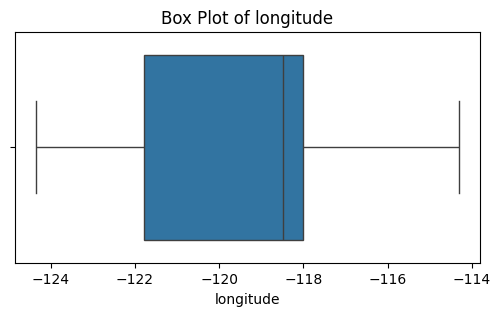

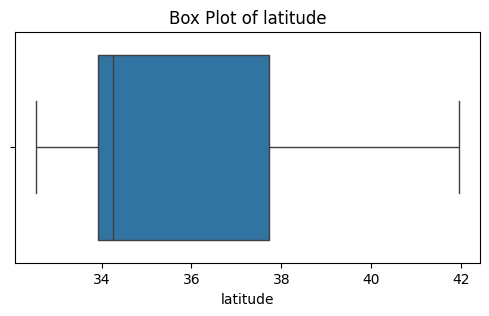

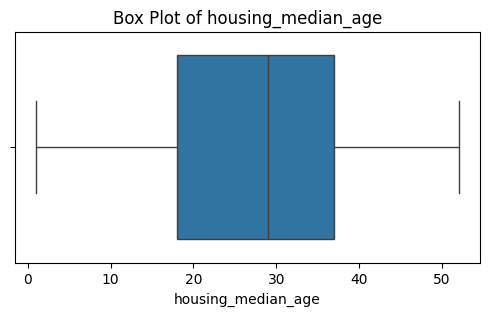

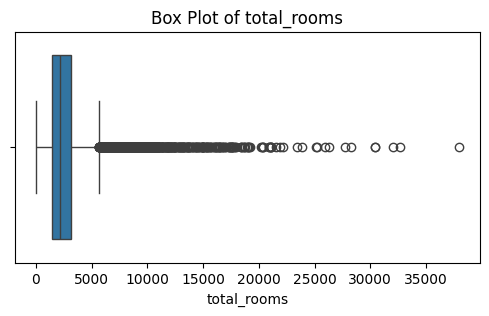

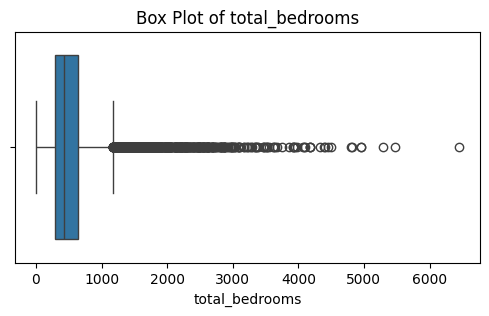

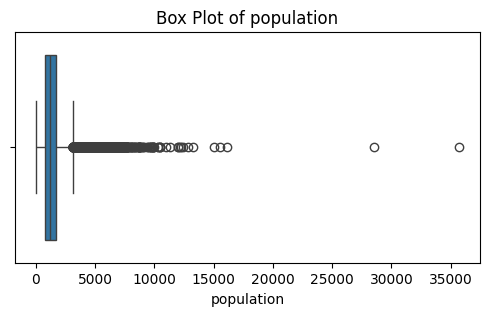

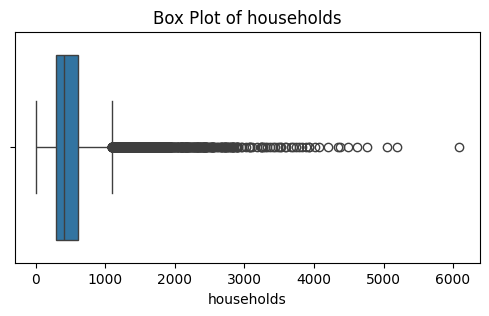

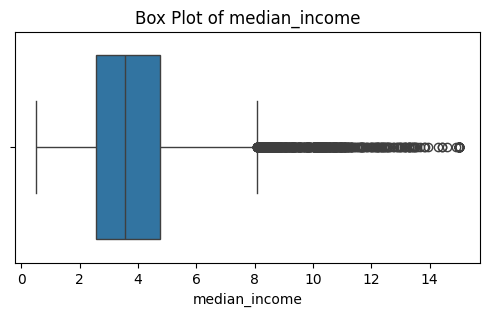

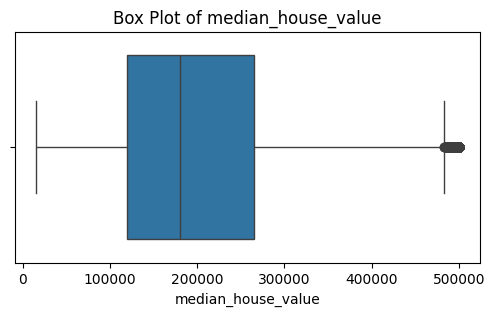

In [51]:
# Box plot
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

In [58]:
# outlier Treatment
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Replace outliers with NaN
    df[col] = np.where(df[col] > upper_bound, np.nan, df[col])
    df[col] = np.where(df[col] < lower_bound, np.nan, df[col])

In [59]:
# Capping Outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
print("Outliers capped successfully.")


Outliers capped successfully.


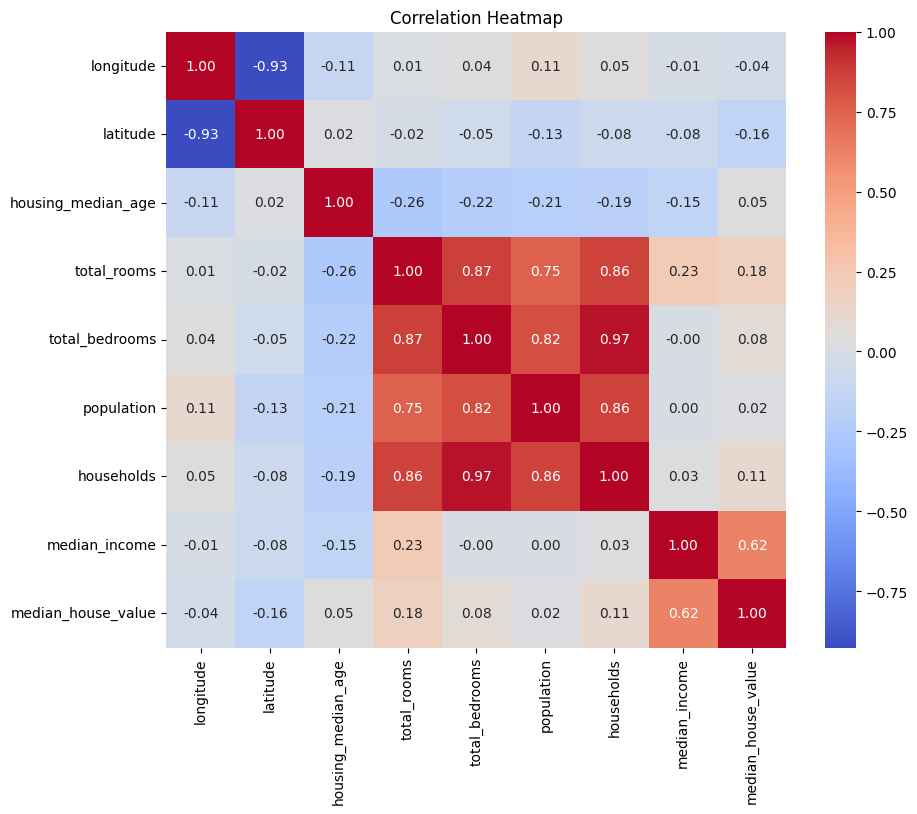

In [60]:
# correlation matrix
corr_matrix = df.corr()
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

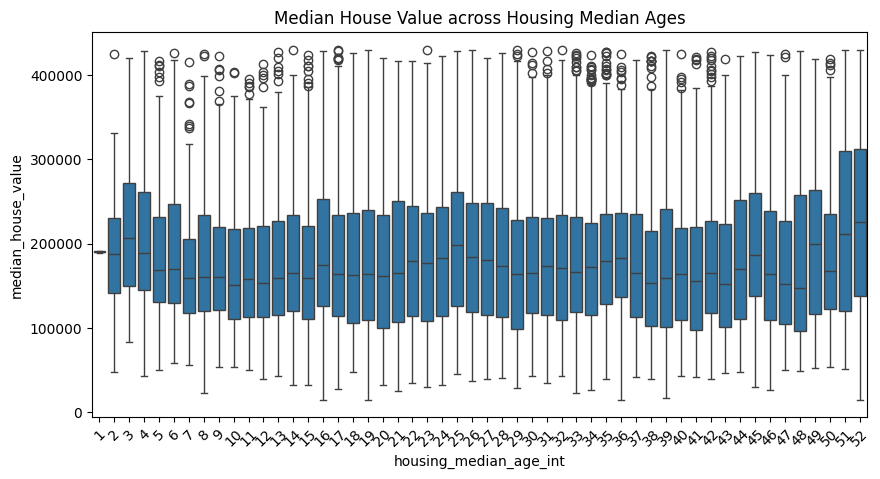

In [62]:
plt.figure(figsize=(10, 5))
# Create a temporary column to treat housing_median_age as discrete categories for plotting
df_plot = df.copy()
df_plot['housing_median_age_int'] = df_plot['housing_median_age'].astype(int)
sns.boxplot(x='housing_median_age_int', y='median_house_value', data=df_plot)
plt.title("Median House Value across Housing Median Ages")
plt.xticks(rotation=45)
plt.show()

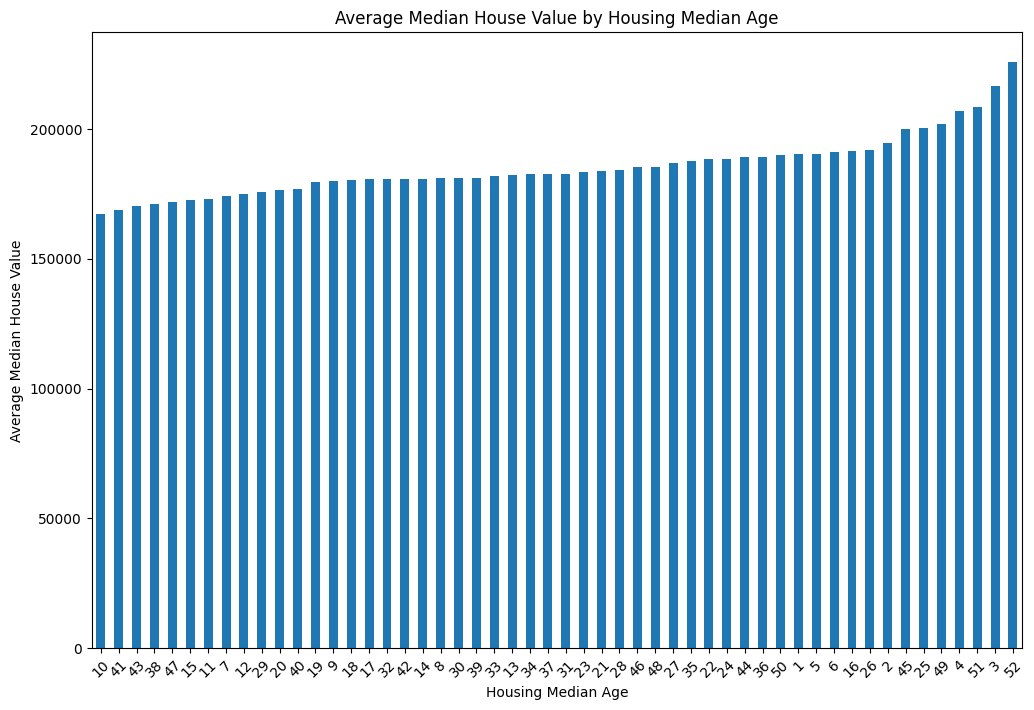

In [64]:
plt.figure(figsize=(12,8))
# Group by integer part of housing_median_age and plot the mean median_house_value
df.groupby(df['housing_median_age'].astype(int))['median_house_value'].mean().sort_values().plot(kind='bar')
plt.title('Average Median House Value by Housing Median Age')
plt.ylabel('Average Median House Value')
plt.xlabel('Housing Median Age')
plt.xticks(rotation=45)
plt.show()

In [68]:
import numpy as np

# Get the unstacked correlation series, filtering out self-correlations and duplicate pairs
upper_tri_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
filtered_correlations = corr_matrix.where(upper_tri_mask).unstack().dropna()

print("strong positive correlation:")
# Sort in descending order to get the strongest positive correlations
print(filtered_correlations.sort_values(ascending=False).head(10))

print("\nstrong negative correlation:")
# Sort in ascending order to get the strongest negative correlations
print(filtered_correlations.sort_values(ascending=True).head(10))

strong positive correlation:
households          total_bedrooms    0.972508
total_bedrooms      total_rooms       0.866317
households          total_rooms       0.861721
                    population        0.858601
population          total_bedrooms    0.820491
                    total_rooms       0.753128
median_house_value  median_income     0.623729
median_income       total_rooms       0.228236
median_house_value  total_rooms       0.180701
                    households        0.105740
dtype: float64

strong negative correlation:
latitude            longitude            -0.925208
total_rooms         housing_median_age   -0.256239
total_bedrooms      housing_median_age   -0.221974
population          housing_median_age   -0.206713
households          housing_median_age   -0.194147
median_house_value  latitude             -0.157163
median_income       housing_median_age   -0.153366
population          latitude             -0.130302
housing_median_age  longitude            -0.1142

In [85]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


In [87]:
# Create Rooms per Household Feature
df['rooms_per_household'] = df['total_rooms'] / df['households']

print(df[['total_rooms', 'households', 'rooms_per_household']].head())

   total_rooms  households  rooms_per_household
0          NaN       472.0                  NaN
1          NaN       463.0                  NaN
2        720.0       117.0             6.153846
3       1501.0       226.0             6.641593
4       1454.0       262.0             5.549618


In [88]:
print(df.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household']


In [77]:
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(cat_cols)

Categorical Columns:
Index([], dtype='object')


In [81]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [82]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(df_encoded.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0          NaN             NaN   
1    -114.47     34.40                19.0          NaN             NaN   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  


In [83]:
print("Original shape", df.shape)
print("Encoded shape:", df_encoded.shape)

Original shape (17000, 9)
Encoded shape: (17000, 9)
